In [6]:
from pathlib import Path
import pandas as pd
import numpy as np

RAW_DIR = Path("../data/raw")

customers = pd.read_csv(RAW_DIR / "customers.csv")
products = pd.read_csv(RAW_DIR / "products.csv")
orders = pd.read_csv(RAW_DIR / "orders.csv")
order_items = pd.read_csv(RAW_DIR / "order_items.csv")

In [7]:
from matplotlib import font_manager
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
# installed_font → installed_fonts (마지막에 's' 누락)
korean_keywords = ["Malgun", "Nanum", "Gulim", "Batang", "AppleGothic"]

In [13]:
korean_font = next(
    (name for name in installed_fonts if any(k in name for k in korean_keywords)),
    None
)

print(korean_font)

if korean_font:
    plt.rcParams["font.family"] = korean_font
plt.rcParams["axes.unicode_minus"] = False


Malgun Gothic Semilight


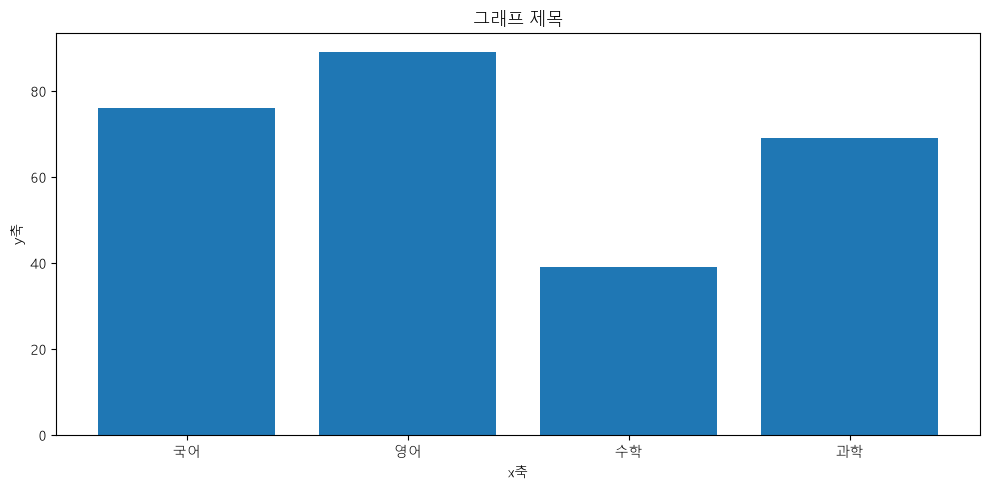

In [14]:
import matplotlib.pyplot as plt

x_data = ["국어","영어","수학", "과학"]
y_data = [76, 89, 39, 69]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_data, y_data)
ax.set_title("그래프 제목")
ax.set_xlabel("x축")
ax.set_ylabel("y축")
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig(
    "graph.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [15]:
orders.head()
orders["order_date"]=pd.to_datetime(orders["order_date"], errors="raise")
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        300 non-null    int64         
 1   customer_id     300 non-null    int64         
 2   order_date      300 non-null    datetime64[us]
 3   payment_method  300 non-null    str           
 4   order_status    300 non-null    str           
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 11.8 KB


In [17]:
products_cleaned = pd.read_csv("https://raw.githubusercontent.com/GilbertMoon/llm-data-analysis-course/refs/heads/main/data/processed/customers_clean.csv")

products_cleaned.head()
products_cleaned.to_csv("../data/processed/products_cleaned.csv", encoding="utf-8-sig")

In [21]:
df_visualization = pd.read_csv(
    "https://raw.githubusercontent.com/GilbertMoon/llm-data-analysis-course/refs/heads/main/data/processed/visualization.csv"
)

df_visualization.to_csv(
    "../data/processed/visualization.csv",
    encoding="utf-8-sig"
)

df_visualization.head()

,order_item_id,order_id,customer_id,product_id,order_date,order_month,order_dayofweek,payment_method,order_status,gender,...,product_name,category,price,quantity,unit_price,line_total,order_match,product_match,customer_match,merge_valid
0,1,1,144.0,39,2026-07-12,2026-07,Sunday,naver_pay,completed,F,...,뷰티 상품 039,뷰티,172000.0,2.0,172000.0,344000.0,True,True,True,True
1,2,2,149.0,26,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,뷰티 상품 026,뷰티,79000.0,4.0,79000.0,316000.0,True,True,True,True
2,3,2,149.0,46,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,생활용품 상품 046,생활용품,87000.0,3.0,87000.0,261000.0,True,True,True,True
3,4,2,149.0,80,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,패션 상품 080,패션,187000.0,1.0,187000.0,187000.0,True,True,True,True
4,5,2,149.0,91,2025-10-02,2025-10,Thursday,kakao_pay,completed,M,...,전자기기 상품 091,전자기기,125000.0,5.0,125000.0,625000.0,True,True,True,True


In [32]:
df_visualization= df_visualization.dropna()
df_visualization.isna().sum().sum()

np.int64(0)

In [34]:
category_sales = df_visualization.groupby("category", as_index=False, dropna=False).agg(
    total_amount=("line_total", "sum"),
    total_quantity=("quantity", "sum")
).sort_values("total_amount", ascending=False)

category_sales["category"] = category_sales["category"].fillna("미분류")

category_sales

,category,total_amount,total_quantity
9,패션,63322000.0,532.0
6,식품,45972000.0,384.0
8,전자기기,34218000.0,280.0
0,도서,27876000.0,272.0
2,뷰티,26467000.0,268.0
5,스포츠,20468000.0,253.0
4,생활용품,13835000.0,204.0
3,생활 용품,3224000.0,26.0
1,뷰 티,1026000.0,19.0
7,전자 기기,252000.0,12.0


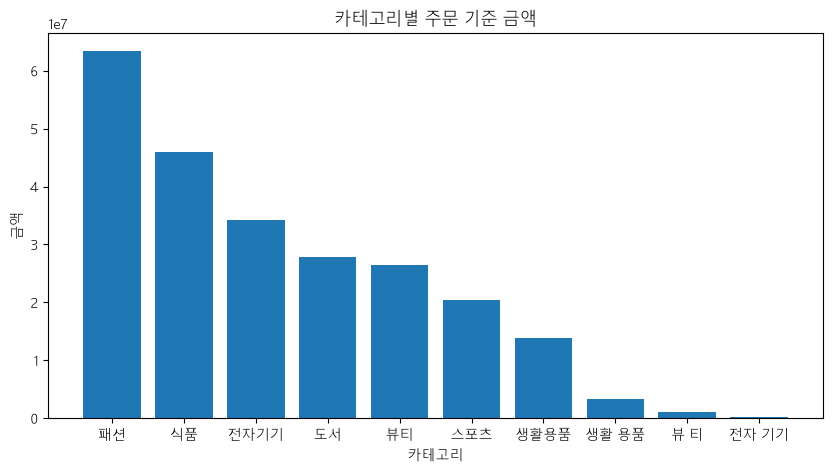

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    category_sales["category"],
    category_sales["total_amount"],
)

ax.set_title("카테고리별 주문 기준 금액")
ax.set_xlabel("카테고리")
ax.set_ylabel("금액")
ax.set_ylim(bottom=0)

plt.show()

In [36]:
df_visualization.columns

Index(['order_item_id', 'order_id', 'customer_id', 'product_id', 'order_date',
       'order_month', 'order_dayofweek', 'payment_method', 'order_status',
       'gender', 'age', 'city', 'signup_date', 'product_name', 'category',
       'price', 'quantity', 'unit_price', 'line_total', 'order_match',
       'product_match', 'customer_match', 'merge_valid'],
      dtype='str')

In [39]:
monthly_sales= df_visualization.groupby(df_visualization["order_month"],as_index=False).agg(
    total_amount = ("line_total","sum"),
    order_count = ("order_id","nunique")
).sort_index()

monthly_sales

,order_month,total_amount,order_count
0,2025-07,13389000.0,18
1,2025-08,31736000.0,24
2,2025-09,12278000.0,12
3,2025-10,16352000.0,22
4,2025-11,12738000.0,22
5,2025-12,15684000.0,23
6,2026-01,18132000.0,25
7,2026-02,13582000.0,18
8,2026-03,13701000.0,22
9,2026-04,19700000.0,24


In [42]:
print(monthly_sales.columns)

Index(['order_month', 'total_amount', 'order_count'], dtype='str')


Text(0, 0.5, '금액')

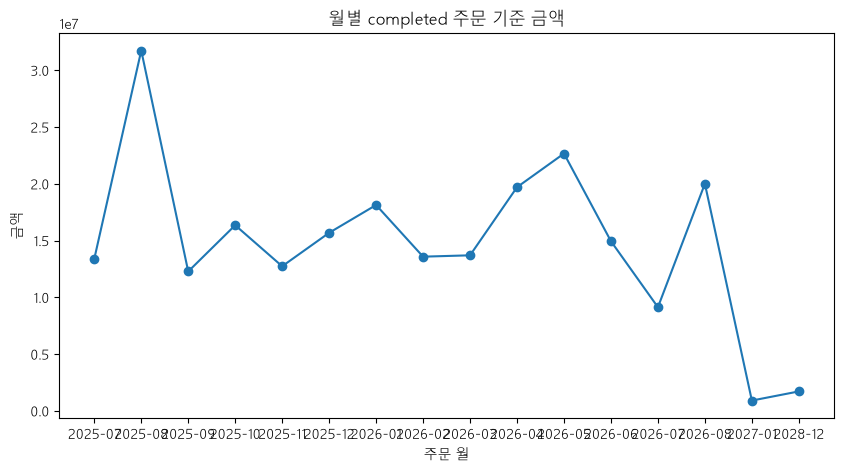

In [ ]:

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    monthly_sales["order_month"],
    monthly_sales["total_amount"],
    marker="o",
)

ax.set_title("월별 total 주문 기준 금액")

ax.set_xlabel("주문 월")

ax.set_ylabel("금액")

Text(0, 0.5, '상품 수')

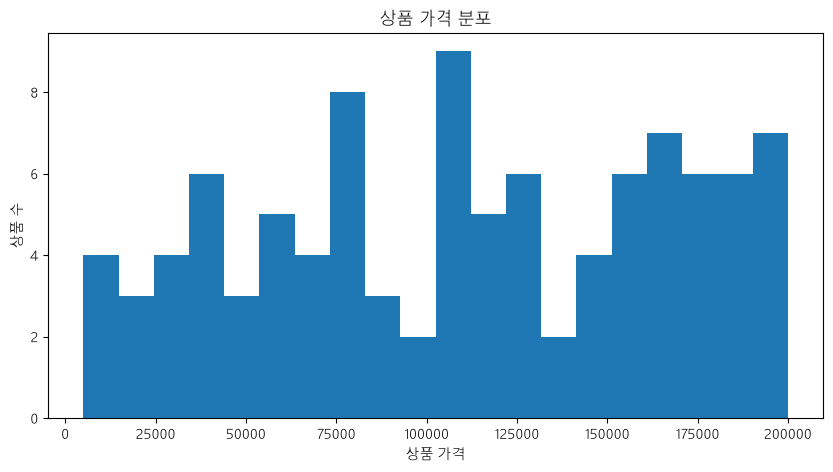

In [43]:

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(

    products["price"],

    bins=20,

)

ax.set_title("상품 가격 분포")

ax.set_xlabel("상품 가격")

ax.set_ylabel("상품 수")

In [46]:
product_quantity = df_visualization.groupby("product_id", as_index=False).agg(
    total_quantity=("quantity","sum")
)
product_quantity

,product_id,total_quantity
0,1,20.0
1,2,19.0
2,3,7.0
3,4,23.0
4,5,24.0
...,...,...
91,96,75.0
92,97,31.0
93,98,25.0
94,99,18.0


In [47]:
product_sales = product_quantity.merge(
    products[["product_id", "price"]],
    on="product_id",
    how="left"
)

product_sales.head()

,product_id,total_quantity,price
0,1,20.0,160000
1,2,19.0,34000
2,3,7.0,152000
3,4,23.0,70000
4,5,24.0,186000


Text(0, 0.5, 'completed 판매 수량')

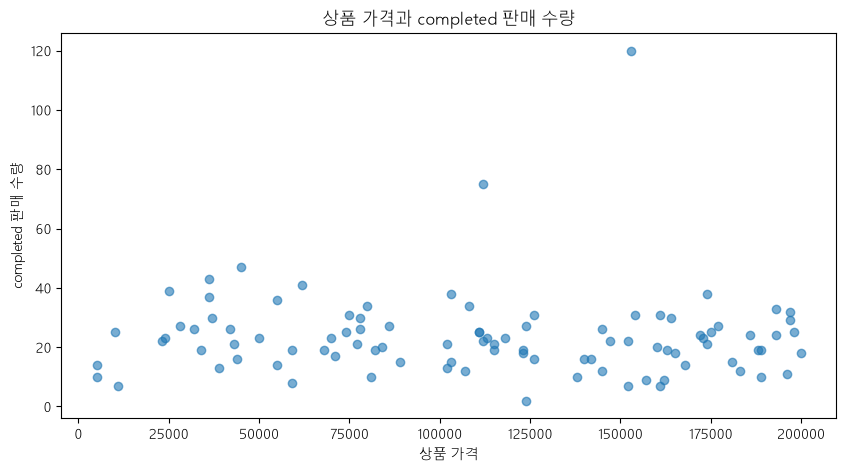

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(

    product_sales["price"],

    product_sales["total_quantity"],

    alpha=0.6,

)

ax.set_title("상품 가격과 completed 판매 수량")

ax.set_xlabel("상품 가격")

ax.set_ylabel("completed 판매 수량")

In [50]:
customer_sales = df_visualization.groupby("customer_id", dropna=False, as_index=False).agg(
    total_amount=("line_total","sum"),
    order_count=("order_id","nunique")
).sort_values("total_amount", ascending=False)

customer_sales

,customer_id,total_amount,order_count
15,18.0,16666000.0,2
2,3.0,8909000.0,7
17,20.0,6200000.0,6
45,52.0,5388000.0,5
11,14.0,5122000.0,4
...,...,...,...
105,131.0,176000.0,1
58,72.0,160000.0,1
70,86.0,128000.0,1
103,129.0,88000.0,1


In [ ]:
top_customers=customer_sales.head(10).reset_index(drop=True)

top_customers







                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

,customer_id,total_amount,order_count
0,18.0,16666000.0,2
1,3.0,8909000.0,7
2,20.0,6200000.0,6
3,52.0,5388000.0,5
4,14.0,5122000.0,4
5,55.0,4850000.0,6
6,90.0,4847000.0,5
7,22.0,4667000.0,4
8,15.0,4281000.0,5
9,115.0,3988000.0,4
